### Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as mtick

# -----------------------------
# IEEE one-column settings
# -----------------------------
plt.rcParams.update({
    "text.usetex": True,              # Usa o LaTeX para renderizar os textos
    "font.family": "serif",           # Define a família da fonte como serif
    "font.serif": ["Times"],          # Especifica a fonte Times
    "axes.labelsize": 9,             # Tamanho da fonte dos eixos (o padrão do texto é 9pt)
    "font.size": 9,                  # Tamanho da fonte geral
    "legend.fontsize": 9,             # Legendas menores (comum em papers)
    "xtick.labelsize": 9,             # Tamanho dos números no eixo X
    "ytick.labelsize": 9,             # Tamanho dos números no eixo Y
    # Caso use símbolos matemáticos, garante que a fonte matemática também seja Times-like
    "text.latex.preamble": r"\usepackage{mathptmx}" 
})

### Undergraduate Courses Abbreviation

In [2]:
abreviacoes_cursos = {
    "Nenhum": "Nenhum",

    # Educação
    "Ciência da educação": "Ciênc. educação",
    # "Formação de professores de educação infantil": "Form. prof. educ. infantil",
    # "Formação de professores sem áreas específicas": "Form. prof. geral",
    # "Formação de professores em áreas específicas (exceto Letras)": "Form. prof. áreas esp.",
    # "Formação de professores de letras": "Form. prof. letras",
    # "Programas interdisciplinares e cursos gerais abrangendo educação": "Interdisc. educação",

    # Formação docente
    "Formação docente para educação infantil": "Form. doc. educ. infantil",
    "Formação docente sem áreas específicas": "Form. doc. geral",
    "Formação docente em áreas específicas (exceto Letras)": "Form. doc. áreas esp.",
    "Formação docente em Letras": "Form. doc. letras",
    "Programas interdisciplinares e cursos gerais abrangendo educação": "Interdisc. educação",

    # Artes e humanidades
    "Produção audiovisual, de mídia e cultural": "Prod. audiovisual/mídia",
    "Moda, design de interiores e desenho industrial": "Moda/design/interiores",
    "Belas artes": "Belas artes",
    "Artesanato": "Artesanato",
    "Música e artes cênicas": "Música/artes cênicas",
    "Religião e teologia": "Religião/teologia",
    "História e arqueologia": "História/arqueologia",
    "Filosofia e ética": "Filosofia/ética",
    "Letras": "Letras",
    "Programas interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. artes/human.",
    "Programas interdisciplinares e cursos gerais abrangindo artes e humanidades": "Interdisc. artes/human. 2",
    "Programa interdisciplinar e curso geral abrangendo artes e humanidades": "Interdisc. artes/human. 3",

    # Ciências sociais, comunicação e informação
    "Economia": "Economia",
    "Ciências sociais e políticas": "Ciênc. sociais/políticas",
    "Psicologia": "Psicologia",
    "Comunicação e reportagem": "Comunicação/reportagem",
    "Ciência da informação e museologia": "Informação/museologia",
    "Programa interdisciplinar e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun.",
    "Programas interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 2",
    "Programa interdisciplinar e curso geral abrangendo ciências sociais, comunicação e informação": "Interdisc. sociais/comun. 3",

    # Negócios, administração e direito
    "Contabilidade e tributação": "Contabilidade/tribut.",
    "Finanças, bancos e seguros": "Finanças/bancos/seguros",
    "Gestão e administração": "Gestão/administração",
    "Marketing e propaganda": "Marketing/propaganda",
    "Secretariado e trabalhos de escritório": "Secretariado/escritório",
    "Gestão comercial": "Gestão comercial",
    "Direito": "Direito",
    "Programas interdisciplinares e cursos gerais abrangendo negócios, administração e direito": "Interdisc. negócios/direito",

    # Ciências naturais, matemática e estatística
    "Biologia": "Biologia",
    "Bioquímica e biotecnologia": "Bioquímica/biotec.",
    "Ciências ambientais": "Ciênc. ambientais",
    "Química": "Química",
    "Ciências da terra": "Ciênc. da terra",
    "Física": "Física",
    "Matemática": "Matemática",
    "Estatística": "Estatística",
    "Programas interdisciplinares e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. ciênc. naturais",
    "Programa interdisciplinar e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. ciênc. naturais 2",

    # Computação e TIC
    "Infraestrutura e gestão de TIC": "Infra./gestão TIC",
    "Produção de software": "Produção software",
    "Ciência da computação": "Ciênc. computação",
    "Gestão e desenvolvimento de sistemas de informação": "Gestão/desenv. sist. info.",
    "Desenvolvimento de sistemas que integram software e hardware": "Sist. software/hardware",
    "Soluções computacionais para domínios específicos": "Soluções computacionais",
    "Programas interdisciplinares e cursos gerais abrangendo computação e Tecnologias da Informação e Comunicação (TIC)": "Interdisc. computação/TIC",

    # Engenharia, produção e construção
    "Engenharia química e de processos": "Eng. química/processos",
    "Tecnologia de proteção ambiental": "Tec. proteção ambiental",
    "Eletricidade e energia": "Eletricidade/energia",
    "Engenharia elétrica e energia": "Eletricidade/energia 2",
    "Eletrônica e automação": "Eletrônica/automação",
    "Engenharia mecânica e metalurgia": "Eng. mecânica/metalurgia",
    "Veículos a motor, construção naval, aeronáutica, ferroviária e metroviária": "Veículos/transp. pesado",
    "Processamento de alimentos": "Proc. alimentos",
    "Materiais": "Materiais",
    "Têxteis (vestuário, calçados e couro)": "Têxteis/vestuário",
    "Mineração e extração": "Mineração/extração",
    "Produção e processos de fabricação": "Produção/fabricação",
    "Arquitetura e planejamento urbano": "Arquitetura/urbanismo",
    "Engenharia civil e construção": "Eng. civil/construção",
    "Programas interdisciplinares e cursos gerais abrangendo engenharia, produção e construção": "Interdisc. eng./produção",

    # Agricultura, silvicultura, pesca e veterinária
    "Produção agrícola, agropecuária e zootecnia": "Agrícola/agropec./zootec.",
    "Horticultura": "Horticultura",
    "Silvicultura": "Silvicultura",
    "Pesca": "Pesca",
    "Veterinária": "Veterinária",
    "Programa interdisciplinar e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agro/vet.",
    "Programas interdisciplinares e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agro/vet. 2",
    "Programa interdisciplinar e curso geral abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agro/vet. 3",

    # Saúde e bem-estar
    "Odontologia": "Odontologia",
    "Medicina": "Medicina",
    "Enfermagem": "Enfermagem",
    "Tecnologia de diagnóstico e tratamento médico": "Diag./tratamento médico",
    "Promoção, prevenção, terapia e reabilitação": "Promoção/terapia/reab.",
    "Farmácia": "Farmácia",
    "Medicina e terapia tradicional e complementar": "Med. tradicional/complementar",
    "Saúde pública e saúde coletiva": "Saúde pública/coletiva",
    # "Assistência a idosos e a deficientes"
    "Assistência a pessoas idosas e a pessoas com deficiência": "Assist. idosos/deficientes",
    "Serviço social": "Serviço social",
    "Programas interdisciplinares e cursos gerais abrangendo saúde e bem-estar": "Interdisc. saúde/bem-estar",

    # Serviços
    "Serviços domésticos": "Serv. domésticos",
    "Serviços de beleza": "Serv. beleza",
    "Serviços de alimentação": "Serv. alimentação",
    "Esportes e lazer": "Esportes/lazer",
    "Turismo e hotelaria": "Turismo/hotelaria",
    "Saúde e segurança no trabalho": "Saúde/segurança trabalho",
    "Setor militar e de defesa": "Militar/defesa",
    "Proteção de pessoas e de propriedades": "Proteção pessoas/propr.",
    "Serviços de transporte": "Serv. transporte",
    "Programas interdisciplinares e cursos gerais abrangendo serviços": "Interdisc. serviços",

    # Respostas especiais
    # "Não sabe": "Não sabe",
    # "Graduação superior mal especificada": "Graduação mal espec.",
}

In [3]:
abreviacoes_cursos_en = {
    "Nenhum": "None",

    # Education
    "Ciência da educação": "Education sci.",

    # Teacher training
    "Formação docente para educação infantil": "Early child. teach.",
    "Formação docente sem áreas específicas": "General teach. train.",
    "Formação docente em áreas específicas (exceto Letras)": "Subject teach. train.",
    "Formação docente em Letras": "Lang./lit. teach.",
    "Programas interdisciplinares e cursos gerais abrangendo educação": "Interdisc. education",

    # Arts and humanities
    "Produção audiovisual, de mídia e cultural": "Audiovisual/media",
    "Moda, design de interiores e desenho industrial": "Fashion/design",
    "Belas artes": "Fine arts",
    "Artesanato": "Crafts",
    "Música e artes cênicas": "Music/perform. arts",
    "Religião e teologia": "Religion/theology",
    "História e arqueologia": "History/archaeology",
    "Filosofia e ética": "Philosophy/ethics",
    "Letras": "Languages/literature",
    "Programas interdisciplinares e cursos gerais abrangendo artes e humanidades": "Interdisc. arts/human.",
    "Programas interdisciplinares e cursos gerais abrangindo artes e humanidades": "Interdisc. arts/human. 2",
    "Programa interdisciplinar e curso geral abrangendo artes e humanidades": "Interdisc. arts/human. 3",

    # Social sciences, communication and information
    "Economia": "Economics",
    "Ciências sociais e políticas": "Social/political sci.",
    "Psicologia": "Psychology",
    "Comunicação e reportagem": "Communication/journal.",
    "Ciência da informação e museologia": "Info. sci./museology",
    "Programa interdisciplinar e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. soc./comm.",
    "Programas interdisciplinares e cursos gerais abrangendo ciências sociais, comunicação e informação": "Interdisc. soc./comm. 2",
    "Programa interdisciplinar e curso geral abrangendo ciências sociais, comunicação e informação": "Interdisc. soc./comm. 3",

    # Business, administration and law
    "Contabilidade e tributação": "Accounting/tax",
    "Finanças, bancos e seguros": "Finance/banking/ins.",
    "Gestão e administração": "Management/admin.",
    "Marketing e propaganda": "Marketing/advert.",
    "Secretariado e trabalhos de escritório": "Secretarial/office",
    "Gestão comercial": "Commercial mgmt.",
    "Direito": "Law",
    "Programas interdisciplinares e cursos gerais abrangendo negócios, administração e direito": "Interdisc. bus./law",

    # Natural sciences, mathematics and statistics
    "Biologia": "Biology",
    "Bioquímica e biotecnologia": "Biochem./biotech.",
    "Ciências ambientais": "Environmental sci.",
    "Química": "Chemistry",
    "Ciências da terra": "Earth sciences",
    "Física": "Physics",
    "Matemática": "Mathematics",
    "Estatística": "Statistics",
    "Programas interdisciplinares e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. nat. sci.",
    "Programa interdisciplinar e cursos gerais abrangendo ciências naturais, matemática e estatística": "Interdisc. nat. sci. 2",

    # Computing and ICT
    "Infraestrutura e gestão de TIC": "ICT infra./mgmt.",
    "Produção de software": "Software production",
    "Ciência da computação": "Computer science",
    "Gestão e desenvolvimento de sistemas de informação": "Info. systems mgmt.",
    "Desenvolvimento de sistemas que integram software e hardware": "Software/hardware sys.",
    "Soluções computacionais para domínios específicos": "Domain comp. solutions",
    "Programas interdisciplinares e cursos gerais abrangendo computação e Tecnologias da Informação e Comunicação (TIC)": "Interdisc. computing/ICT",

    # Engineering, manufacturing and construction
    "Engenharia química e de processos": "Chem./process eng.",
    "Tecnologia de proteção ambiental": "Env. protection tech.",
    "Eletricidade e energia": "Electricity/energy",
    "Engenharia elétrica e energia": "Electrical/energy eng.",
    "Eletrônica e automação": "Electronics/automation",
    "Engenharia mecânica e metalurgia": "Mech. eng./metallurgy",
    "Veículos a motor, construção naval, aeronáutica, ferroviária e metroviária": "Vehicles/heavy transp.",
    "Processamento de alimentos": "Food processing",
    "Materiais": "Materials",
    "Têxteis (vestuário, calçados e couro)": "Textiles/apparel",
    "Mineração e extração": "Mining/extraction",
    "Produção e processos de fabricação": "Manufacturing/processes",
    "Arquitetura e planejamento urbano": "Architecture/urban plan.",
    "Engenharia civil e construção": "Civil eng./construction",
    "Programas interdisciplinares e cursos gerais abrangendo engenharia, produção e construção": "Interdisc. eng./manuf.",

    # Agriculture, forestry, fisheries and veterinary
    "Produção agrícola, agropecuária e zootecnia": "Agric./livestock",
    "Horticultura": "Horticulture",
    "Silvicultura": "Forestry",
    "Pesca": "Fisheries",
    "Veterinária": "Veterinary",
    "Programa interdisciplinar e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agri./vet.",
    "Programas interdisciplinares e cursos gerais abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agri./vet. 2",
    "Programa interdisciplinar e curso geral abrangendo agricultura, silvicultura, pesca e veterinária": "Interdisc. agri./vet. 3",

    # Health and welfare
    "Odontologia": "Dentistry",
    "Medicina": "Medicine",
    "Enfermagem": "Nursing",
    "Tecnologia de diagnóstico e tratamento médico": "Med. diagnosis/treat.",
    "Promoção, prevenção, terapia e reabilitação": "Promotion/therapy/rehab.",
    "Farmácia": "Pharmacy",
    "Medicina e terapia tradicional e complementar": "Trad./complement. med.",
    "Saúde pública e saúde coletiva": "Public/collective health",
    "Assistência a pessoas idosas e a pessoas com deficiência": "Elderly/disability care",
    "Serviço social": "Social work",
    "Programas interdisciplinares e cursos gerais abrangendo saúde e bem-estar": "Interdisc. health/welfare",

    # Services
    "Serviços domésticos": "Domestic services",
    "Serviços de beleza": "Beauty services",
    "Serviços de alimentação": "Food services",
    "Esportes e lazer": "Sports/leisure",
    "Turismo e hotelaria": "Tourism/hospitality",
    "Saúde e segurança no trabalho": "Occup. health/safety",
    "Setor militar e de defesa": "Military/defense",
    "Proteção de pessoas e de propriedades": "Personal/property prot.",
    "Serviços de transporte": "Transport services",
    "Programas interdisciplinares e cursos gerais abrangendo serviços": "Interdisc. services",

    # Special responses
    # "Não sabe": "Does not know",
    # "Graduação superior mal especificada": "Poorly specified degree",
}

### Read Answers and Process JSON

In [4]:
df = pd.read_csv("../../data/generated_profiles.csv")
df.head(10)

,modelo,temperatura,repeticao,system_prompt,user_prompt,resposta_raw
0,openai/gpt-oss-120b,0.0,1,{},"{'graduacao_codigo': '0111', 'graduacao_descri...","{""nome"":""Mariana Silva"",""idade"":34,""estado"":""S..."
1,google/gemini-2.5-flash,0.0,1,{},"{'graduacao_codigo': '0111', 'graduacao_descri...",<think>\nMy task is to construct a JSON object...
2,google/gemma-4-31B-it,0.0,1,{},"{'graduacao_codigo': '0111', 'graduacao_descri...","{\n""nome"": ""Mariana Silva Oliveira"",\n""idade"":..."
3,sabia-4,0.0,1,{},"{'graduacao_codigo': '0111', 'graduacao_descri...","{""nome"":""Ana Beatriz Souza"",""idade"":34,""estado..."
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,0.0,1,{},"{'graduacao_codigo': '0111', 'graduacao_descri...","{""nome"": ""Luana"", ""idade"": 32, ""estado"": ""SP"",..."
5,deepseek-ai/DeepSeek-V4-Pro,0.0,1,{},"{'graduacao_codigo': '0111', 'graduacao_descri...","{""nome"": ""Helena Fonseca"", ""idade"": 41, ""estad..."
6,mistralai/Mistral-Small-3.2-24B-Instruct-2506,0.0,1,{},"{'graduacao_codigo': '0111', 'graduacao_descri...","{\n ""nome"": ""Ana Silva"",\n ""idade"": 32,\n ""..."
7,Qwen/Qwen3-235B-A22B-Instruct-2507,0.0,1,{},"{'graduacao_codigo': '0111', 'graduacao_descri...","{""nome"":""Carla Mendes Silva"",""idade"":34,""estad..."
8,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,0.0,1,{},"{'graduacao_codigo': '0111', 'graduacao_descri...","{""nome"":""Ana Silva"",""idade"":32,""estado"":""SP"",""..."
9,openai/gpt-oss-120b,0.0,1,{},"{'graduacao_codigo': '0112', 'graduacao_descri...","{""nome"":""Mariana Silva"",""idade"":32,""estado"":""S..."


In [5]:
# Pegar o JSON da coluna resposta e transformar em colunas separadas
df[['graduacao_codigo', 'graduacao_descricao', 'graduacao']] = df["user_prompt"].apply(lambda x: pd.Series(eval(x)))

# Remover coluna graduacao
df.drop(columns=["graduacao", "temperatura", "repeticao", "system_prompt"], inplace=True)

# mostrar
df.head()

,modelo,user_prompt,resposta_raw,graduacao_codigo,graduacao_descricao
0,openai/gpt-oss-120b,"{'graduacao_codigo': '0111', 'graduacao_descri...","{""nome"":""Mariana Silva"",""idade"":34,""estado"":""S...",0111,Ciência da educação
1,google/gemini-2.5-flash,"{'graduacao_codigo': '0111', 'graduacao_descri...",<think>\nMy task is to construct a JSON object...,0111,Ciência da educação
2,google/gemma-4-31B-it,"{'graduacao_codigo': '0111', 'graduacao_descri...","{\n""nome"": ""Mariana Silva Oliveira"",\n""idade"":...",0111,Ciência da educação
3,sabia-4,"{'graduacao_codigo': '0111', 'graduacao_descri...","{""nome"":""Ana Beatriz Souza"",""idade"":34,""estado...",0111,Ciência da educação
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,"{'graduacao_codigo': '0111', 'graduacao_descri...","{""nome"": ""Luana"", ""idade"": 32, ""estado"": ""SP"",...",0111,Ciência da educação


In [6]:
# # Remover think step
def remove_think_step(text):
    if "</think>" in text:
        text = text.split("</think>")[1]
    return text
df["resposta_raw"] = df["resposta_raw"].apply(lambda x: remove_think_step(x))

In [7]:
# Ver quantos JSONs tem em cada resposta_raw 
# (pode conter texto adicional além do JSON, mais de um JSON, ou apenas um JSON)
df["resposta_raw"].apply(lambda x: x.count("{")).value_counts()

resposta_raw
1    766
0     17
Name: count, dtype: int64

In [8]:
# Ver quais linhas não possuem JSON (0 chaves)
df[df["resposta_raw"].apply(lambda x: x.count("{") == 0)]

,modelo,user_prompt,resposta_raw,graduacao_codigo,graduacao_descricao
125,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0223', 'graduacao_descri...",We need to output JSON,0223,Filosofia e ética
143,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0288', 'graduacao_descri...",We need to output JSON with the following,0288,Programas interdisciplinares e cursos gerais a...
152,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0311', 'graduacao_descri...",We need to output a JSON object,0311,Economia
161,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0312', 'graduacao_descri...",We need to output a JSON object,0312,Ciências sociais e políticas
170,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0313', 'graduacao_descri...",We need to output a JSON object with keys: nom...,0313,Psicologia
179,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0321', 'graduacao_descri...",We need to output JSON,0321,Comunicação e reportagem
215,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0412', 'graduacao_descri...",We need to output a JSON object with the follo...,0412,"Finanças, bancos e seguros"
224,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0413', 'graduacao_descri...",We need to return a JSON object with the follo...,0413,Gestão e administração
233,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0414', 'graduacao_descri...",We need to,0414,Marketing e propaganda
242,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0415', 'graduacao_descri...",We need to produce a JSON object with the requ...,0415,Secretariado e trabalhos de escritório


In [9]:
# Checar se todos os JSONs possuem as chaves esperadas (nome, idade, estado, renda_mensal, sexo_atribuido, cor_ou_raca)
chaves_esperadas = {"nome", "idade", "estado", "renda_mensal", "sexo_atribuido", "cor_ou_raca"}
def checar_chaves(texto):
    try:
        resposta_json = eval(texto)
        if isinstance(resposta_json, dict):
            return chaves_esperadas.issubset(resposta_json.keys())
        elif isinstance(resposta_json, list):
            return all(chaves_esperadas.issubset(item.keys()) for item in resposta_json if isinstance(item, dict))
        else:       
          return False
    except:
        return False

df["resposta_valida"] = df["resposta_raw"].apply(checar_chaves)

In [10]:
# Verificar quantas respostas são válidas
df["resposta_valida"].value_counts()

resposta_valida
True     763
False     20
Name: count, dtype: int64

In [11]:
# Mostrar as respostas inválidas para entender o que tem de errado
df[~df["resposta_valida"]]

,modelo,user_prompt,resposta_raw,graduacao_codigo,graduacao_descricao,resposta_valida
125,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0223', 'graduacao_descri...",We need to output JSON,0223,Filosofia e ética,False
134,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0231', 'graduacao_descri...","We need to output a JSON object\n{""name"":",0231,Letras,False
143,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0288', 'graduacao_descri...",We need to output JSON with the following,0288,Programas interdisciplinares e cursos gerais a...,False
152,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0311', 'graduacao_descri...",We need to output a JSON object,0311,Economia,False
161,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0312', 'graduacao_descri...",We need to output a JSON object,0312,Ciências sociais e políticas,False
170,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0313', 'graduacao_descri...",We need to output a JSON object with keys: nom...,0313,Psicologia,False
179,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0321', 'graduacao_descri...",We need to output JSON,0321,Comunicação e reportagem,False
215,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0412', 'graduacao_descri...",We need to output a JSON object with the follo...,0412,"Finanças, bancos e seguros",False
224,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0413', 'graduacao_descri...",We need to return a JSON object with the follo...,0413,Gestão e administração,False
233,nvidia/NVIDIA-Nemotron-3-Super-120B-A12B,"{'graduacao_codigo': '0414', 'graduacao_descri...",We need to,0414,Marketing e propaganda,False


In [12]:
# Remover o nvidia/NVIDIA-Nemotron-3-Super-120B-A12B
df = df[df["modelo"] != "nvidia/NVIDIA-Nemotron-3-Super-120B-A12B"]

# Checar se as demais respostas são válidas
df["resposta_valida"].value_counts()

resposta_valida
True    696
Name: count, dtype: int64

In [13]:
# - "nome": "...",
# - "idade": 0,
# - "estado": "...",
# - "renda_mensal": 0,
# - "sexo_atribuido": "...",
# - "cor_ou_raca": "..."

# Pegar o que tá dentro {}, remover '\n' e espaços extras, e transformar em colunas separadas
def extract_json(text):
    if "{" in text and "}" in text:
        json_str = text[text.find("{"):text.rfind("}")+1]
        json_str = json_str.replace("\n", "").strip()
        try:
            return eval(json_str)
        except:
            return {}
    return {}
df["resposta_json"] = df["resposta_raw"].apply(lambda x: extract_json(x))
df[["nome", "idade", "estado", "renda_mensal", "sexo_atribuido", "cor_ou_raca"]] = df["resposta_json"].apply(lambda x: pd.Series({
    "nome": x.get("nome", ""),
    "idade": x.get("idade", 0),
    "estado": x.get("estado", ""),
    "renda_mensal": x.get("renda_mensal", 0),
    "sexo_atribuido": x.get("sexo_atribuido", ""),
    "cor_ou_raca": x.get("cor_ou_raca", "")
}))

In [14]:
# Verificar se todos esses atributos tem valores válidos (idade e renda_mensal são inteiros, os outros são strings não vazias)
def is_valid(row):
    if not isinstance(row["idade"], int) or row["idade"] < 0:
        return False
    if not isinstance(row["renda_mensal"], int) or row["renda_mensal"] < 0:
        return False
    if not isinstance(row["nome"], str) or row["nome"].strip() == "":
        return False
    if not isinstance(row["estado"], str) or row["estado"].strip() == "":
        return False
    if not isinstance(row["sexo_atribuido"], str) or row["sexo_atribuido"].strip() == "":
        return False
    if not isinstance(row["cor_ou_raca"], str) or row["cor_ou_raca"].strip() == "":
        return False
    return True
df["resposta_valida"] = df.apply(lambda row: is_valid(row), axis=1)
df[~df["resposta_valida"]]

,modelo,user_prompt,resposta_raw,graduacao_codigo,graduacao_descricao,resposta_valida,resposta_json,nome,idade,estado,renda_mensal,sexo_atribuido,cor_ou_raca


In [15]:
# Print all and see the invalid response
df[~df["resposta_valida"]]['resposta_raw'].values[:20]

<StringArray>
[]
Length: 0, dtype: str

### Select Columns

In [16]:
df_subset = df[["modelo", "graduacao_codigo", "graduacao_descricao", "nome", "idade", "estado", "renda_mensal", "sexo_atribuido", "cor_ou_raca"]]
df_subset.head(5)

,modelo,graduacao_codigo,graduacao_descricao,nome,idade,estado,renda_mensal,sexo_atribuido,cor_ou_raca
0,openai/gpt-oss-120b,0111,Ciência da educação,Mariana Silva,34,SP,5500,feminino,parda
1,google/gemini-2.5-flash,0111,Ciência da educação,Ana Paula Silva,35,SP,4500,feminino,parda
2,google/gemma-4-31B-it,0111,Ciência da educação,Mariana Silva Oliveira,34,SP,4500,feminino,parda
3,sabia-4,0111,Ciência da educação,Ana Beatriz Souza,34,SP,4200,feminino,branca
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,0111,Ciência da educação,Luana,32,SP,4500,feminino,parda


### Get IBGE Data and Join

In [17]:
df_ibge = pd.read_excel("../../data/tables/ibge_undergraduate_fields.xlsx")
df_ibge.head(10)

,"Tabela 10065 - Pessoas com nível superior completo, por áreas gerais, específicas e detalhadas de formação do curso graduação concluído, segundo o sexo e a cor ou raça",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Variável - Pessoas com pelo menos nível superi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Brasil, Grande Região e Unidade da Federação","Áreas gerais, específicas e detalhadas de form...",Ano x Sexo x Cor ou raça,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Total,NaN,NaN,NaN,NaN,NaN,Homens,NaN,NaN,NaN,NaN,NaN,Mulheres,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Total,Branca,Preta,Amarela,Parda,Indígena,Total,Branca,Preta,Amarela,Parda,Indígena,Total,Branca,Preta,Amarela,Parda,Indígena
5,Brasil,Total,25854291,16118188,1833183,300446,7542900,54107,10478534,6635081,743938,141776,2933180,22134,15375757,9483107,1089245,158670,4609720,31973
6,NaN,01 - Educação,3601124,1923858,316670,17759,1328413,13794,376719,173735,41279,2535,154831,4162,3224405,1750123,275391,15224,1173582,9632
7,NaN,011 - Educação,3564975,1901869,313519,17544,1317843,13570,366686,168211,40133,2486,151599,4081,3198289,1733658,273386,15058,1166244,9489
8,NaN,0111 - Ciência da educação,133309,71369,10857,367,50247,459,14011,6952,1357,46,5547,108,119297,64417,9500,320,44700,350
9,NaN,0112 - Formação de professores de educação inf...,19207,9753,1780,45,7510,119,588,251,91,6,236,5,18619,9502,1689,40,7274,114


In [18]:
# Colocar a linha 5 como colunas
df_ibge.columns = df_ibge.iloc[4]
df_ibge = df_ibge.drop(index=range(0, 5))
df_ibge.head(10)

4,NaN,NaN,Total,Branca,Preta,Amarela,Parda,Indígena,Total,Branca,Preta,Amarela,Parda,Indígena,Total,Branca,Preta,Amarela,Parda,Indígena
5,Brasil,Total,25854291,16118188,1833183,300446,7542900,54107,10478534,6635081,743938,141776,2933180,22134,15375757,9483107,1089245,158670,4609720,31973
6,NaN,01 - Educação,3601124,1923858,316670,17759,1328413,13794,376719,173735,41279,2535,154831,4162,3224405,1750123,275391,15224,1173582,9632
7,NaN,011 - Educação,3564975,1901869,313519,17544,1317843,13570,366686,168211,40133,2486,151599,4081,3198289,1733658,273386,15058,1166244,9489
8,NaN,0111 - Ciência da educação,133309,71369,10857,367,50247,459,14011,6952,1357,46,5547,108,119297,64417,9500,320,44700,350
9,NaN,0112 - Formação de professores de educação inf...,19207,9753,1780,45,7510,119,588,251,91,6,236,5,18619,9502,1689,40,7274,114
10,NaN,0113 - Formação de professores sem áreas espec...,3108277,1640654,276647,12790,1165759,11881,222975,91867,25896,872,100935,3297,2885302,1548787,250751,11918,1064824,8584
11,NaN,0114 - Formação de professores em áreas especí...,292953,173550,23271,4182,90778,1096,127021,68199,12540,1513,44043,657,165931,105351,10730,2669,46735,440
12,NaN,0115 - Formação de professores de letras,11230,6543,963,160,3549,15,2090,942,248,48,837,14,9139,5600,715,112,2711,1
13,NaN,018 - Programas interdisciplinares e cursos ge...,36149,21989,3151,215,10570,224,10033,5524,1146,49,3232,81,26117,16465,2005,165,7338,143
14,NaN,0188 - Programas interdisciplinares e cursos ...,36149,21989,3151,215,10570,224,10033,5524,1146,49,3232,81,26117,16465,2005,165,7338,143


In [19]:
cols = list(df_ibge.columns)
cols[0] = "Local"
cols[1] = "Area"
df_ibge.columns = cols

df_ibge.head(10)

,Local,Area,Total,Branca,Preta,Amarela,Parda,Indígena,Total,Branca,Preta,Amarela,Parda,Indígena,Total,Branca,Preta,Amarela,Parda,Indígena
5,Brasil,Total,25854291,16118188,1833183,300446,7542900,54107,10478534,6635081,743938,141776,2933180,22134,15375757,9483107,1089245,158670,4609720,31973
6,NaN,01 - Educação,3601124,1923858,316670,17759,1328413,13794,376719,173735,41279,2535,154831,4162,3224405,1750123,275391,15224,1173582,9632
7,NaN,011 - Educação,3564975,1901869,313519,17544,1317843,13570,366686,168211,40133,2486,151599,4081,3198289,1733658,273386,15058,1166244,9489
8,NaN,0111 - Ciência da educação,133309,71369,10857,367,50247,459,14011,6952,1357,46,5547,108,119297,64417,9500,320,44700,350
9,NaN,0112 - Formação de professores de educação inf...,19207,9753,1780,45,7510,119,588,251,91,6,236,5,18619,9502,1689,40,7274,114
10,NaN,0113 - Formação de professores sem áreas espec...,3108277,1640654,276647,12790,1165759,11881,222975,91867,25896,872,100935,3297,2885302,1548787,250751,11918,1064824,8584
11,NaN,0114 - Formação de professores em áreas especí...,292953,173550,23271,4182,90778,1096,127021,68199,12540,1513,44043,657,165931,105351,10730,2669,46735,440
12,NaN,0115 - Formação de professores de letras,11230,6543,963,160,3549,15,2090,942,248,48,837,14,9139,5600,715,112,2711,1
13,NaN,018 - Programas interdisciplinares e cursos ge...,36149,21989,3151,215,10570,224,10033,5524,1146,49,3232,81,26117,16465,2005,165,7338,143
14,NaN,0188 - Programas interdisciplinares e cursos ...,36149,21989,3151,215,10570,224,10033,5524,1146,49,3232,81,26117,16465,2005,165,7338,143


In [20]:
df_ibge.info()

<class 'pandas.DataFrame'>
RangeIndex: 4588 entries, 5 to 4592
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Local     34 non-null     str   
 1   Area      4587 non-null   str   
 2   Total     4587 non-null   object
 3   Branca    4587 non-null   object
 4   Preta     4587 non-null   object
 5   Amarela   4587 non-null   object
 6   Parda     4587 non-null   object
 7   Indígena  4587 non-null   object
 8   Total     4587 non-null   object
 9   Branca    4587 non-null   object
 10  Preta     4587 non-null   object
 11  Amarela   4587 non-null   object
 12  Parda     4587 non-null   object
 13  Indígena  4587 non-null   object
 14  Total     4587 non-null   object
 15  Branca    4587 non-null   object
 16  Preta     4587 non-null   object
 17  Amarela   4587 non-null   object
 18  Parda     4587 non-null   object
 19  Indígena  4587 non-null   object
dtypes: object(18), str(2)
memory usage: 717.0+ KB


In [21]:
# 1. Definimos os prefixos para cada intervalo de colunas
prefixos = (
    ["Id"] * 2 +
    ["Pessoas"] * 6 +
    ["Homens"] * 6 +
    ["Mulheres"] * 6
)

# 2. Pegamos os nomes atuais das colunas
nomes_originais = df_ibge.columns.astype(str)

# 3. Criamos nomes simples com prefixo
novas_colunas = [
    f"{prefixo}_{nome}".strip()
    for prefixo, nome in zip(prefixos, nomes_originais)
]

# 4. Atribuímos as novas colunas ao dataframe
df_ibge.columns = novas_colunas

# 5. Preenche os valores vazios da coluna de localidade
df_ibge["Id_Local"] = df_ibge["Id_Local"].ffill()

df_ibge.head()

,Id_Local,Id_Area,Pessoas_Total,Pessoas_Branca,Pessoas_Preta,Pessoas_Amarela,Pessoas_Parda,Pessoas_Indígena,Homens_Total,Homens_Branca,Homens_Preta,Homens_Amarela,Homens_Parda,Homens_Indígena,Mulheres_Total,Mulheres_Branca,Mulheres_Preta,Mulheres_Amarela,Mulheres_Parda,Mulheres_Indígena
5,Brasil,Total,25854291,16118188,1833183,300446,7542900,54107,10478534,6635081,743938,141776,2933180,22134,15375757,9483107,1089245,158670,4609720,31973
6,Brasil,01 - Educação,3601124,1923858,316670,17759,1328413,13794,376719,173735,41279,2535,154831,4162,3224405,1750123,275391,15224,1173582,9632
7,Brasil,011 - Educação,3564975,1901869,313519,17544,1317843,13570,366686,168211,40133,2486,151599,4081,3198289,1733658,273386,15058,1166244,9489
8,Brasil,0111 - Ciência da educação,133309,71369,10857,367,50247,459,14011,6952,1357,46,5547,108,119297,64417,9500,320,44700,350
9,Brasil,0112 - Formação de professores de educação inf...,19207,9753,1780,45,7510,119,588,251,91,6,236,5,18619,9502,1689,40,7274,114


In [22]:
# mostrar linhas com NaNs e remover ultima linha
df_ibge[df_ibge.isna().any(axis=1)]
print(df_ibge.shape[0])

4588


In [23]:
df_ibge = df_ibge.dropna()
print(df_ibge.shape[0])

4587


In [24]:
def adicionar_hierarquia_area(df, coluna_area=("Id", "Area")):
    df = df.copy()

    extraido = (
        df[coluna_area]
        .astype("string")
        .str.strip()
        .str.extract(r"^(?P<codigo>\d+)\s*-\s*(?P<descricao>.+)$")
    )

    df["codigo_area"] = extraido["codigo"]
    df["descricao_area"] = extraido["descricao"].str.strip()

    # Mapas com os nomes dos grupos e subgrupos
    mapa_grupo = (
        df.loc[df["codigo_area"].str.len().eq(2), ["codigo_area", "descricao_area"]]
        .drop_duplicates()
        .set_index("codigo_area")["descricao_area"]
        .to_dict()
    )

    mapa_subgrupo = (
        df.loc[df["codigo_area"].str.len().eq(3), ["codigo_area", "descricao_area"]]
        .drop_duplicates()
        .set_index("codigo_area")["descricao_area"]
        .to_dict()
    )

    df["codigo_grupo"] = df["codigo_area"].str[:2]
    df["codigo_subgrupo"] = df["codigo_area"].str[:3]

    df["grupo"] = df["codigo_grupo"].map(mapa_grupo)
    df["subgrupo"] = df["codigo_subgrupo"].map(mapa_subgrupo)

    df["nome_area"] = df["descricao_area"].where(
        df["codigo_area"].str.len().ge(4)
    )

    return df

df_ibge = adicionar_hierarquia_area(df_ibge, coluna_area=("Id_Area"))

In [25]:
# Garantir string, preencher ausentes e normalizar espaços internos
df_ibge["nome_area"] = (
    df_ibge["nome_area"]
    .fillna("Nenhum")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)  # troca múltiplos espaços por um só
    .str.strip()
)

In [26]:
# Pegar código de Id_Area (split('-')) e strip()
# df_ibge["codigo"] = df_ibge["Id_Area"].str.split("-").str[0].str.strip()
# df_ibge.head()

In [27]:
df_ibge = df_ibge[df_ibge['Id_Local']=="Brasil"].copy()

### Merge

In [28]:
# Merge em 'codigo' e 'graduacao_codigo'
# Manter apenas linhas do df_subset
df_merged = pd.merge(df_subset, df_ibge, left_on="graduacao_codigo", right_on="codigo_area", how="inner")
df_merged.head()

,modelo,graduacao_codigo,graduacao_descricao,nome,idade,estado,renda_mensal,sexo_atribuido,cor_ou_raca,Id_Local,...,Mulheres_Amarela,Mulheres_Parda,Mulheres_Indígena,codigo_area,descricao_area,codigo_grupo,codigo_subgrupo,grupo,subgrupo,nome_area
0,openai/gpt-oss-120b,0111,Ciência da educação,Mariana Silva,34,SP,5500,feminino,parda,Brasil,...,320,44700,350,0111,Ciência da educação,01,011,Educação,Educação,Ciência da educação
1,google/gemini-2.5-flash,0111,Ciência da educação,Ana Paula Silva,35,SP,4500,feminino,parda,Brasil,...,320,44700,350,0111,Ciência da educação,01,011,Educação,Educação,Ciência da educação
2,google/gemma-4-31B-it,0111,Ciência da educação,Mariana Silva Oliveira,34,SP,4500,feminino,parda,Brasil,...,320,44700,350,0111,Ciência da educação,01,011,Educação,Educação,Ciência da educação
3,sabia-4,0111,Ciência da educação,Ana Beatriz Souza,34,SP,4200,feminino,branca,Brasil,...,320,44700,350,0111,Ciência da educação,01,011,Educação,Educação,Ciência da educação
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,0111,Ciência da educação,Luana,32,SP,4500,feminino,parda,Brasil,...,320,44700,350,0111,Ciência da educação,01,011,Educação,Educação,Ciência da educação


In [29]:
print(len(df_subset), len(df_ibge), len(df_merged))

696 139 696


### Analysis

In [30]:
# Delete df to avoid confusion
del df, df_subset, df_ibge

##### Models Used

In [31]:
##### Models Used
df_merged["modelo"].value_counts()

modelo
openai/gpt-oss-120b                                  87
google/gemini-2.5-flash                              87
google/gemma-4-31B-it                                87
sabia-4                                              87
meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8    87
deepseek-ai/DeepSeek-V4-Pro                          87
mistralai/Mistral-Small-3.2-24B-Instruct-2506        87
Qwen/Qwen3-235B-A22B-Instruct-2507                   87
Name: count, dtype: int64

##### Verify if LLMs Answers are on Correct Setting

In [32]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   modelo               696 non-null    str   
 1   graduacao_codigo     696 non-null    object
 2   graduacao_descricao  696 non-null    str   
 3   nome                 696 non-null    str   
 4   idade                696 non-null    int64 
 5   estado               696 non-null    str   
 6   renda_mensal         696 non-null    int64 
 7   sexo_atribuido       696 non-null    str   
 8   cor_ou_raca          696 non-null    str   
 9   Id_Local             696 non-null    str   
 10  Id_Area              696 non-null    str   
 11  Pessoas_Total        696 non-null    object
 12  Pessoas_Branca       696 non-null    object
 13  Pessoas_Preta        696 non-null    object
 14  Pessoas_Amarela      696 non-null    object
 15  Pessoas_Parda        696 non-null    object
 16  Pessoas_Indígena   

In [33]:
# Remover gpt-5 nano
df_merged = df_merged[df_merged["modelo"] != "gpt-5-nano"].copy()

In [34]:
# Verificar os valores em sexo e cor ou raça
print("Valores únicos em sexo_atribuido:", df_merged["sexo_atribuido"].unique())
print("Valores únicos em cor_ou_raca:", df_merged["cor_ou_raca"].unique())

Valores únicos em sexo_atribuido: <StringArray>
['feminino', 'masculino']
Length: 2, dtype: str
Valores únicos em cor_ou_raca: <StringArray>
['parda', 'branca', 'preta']
Length: 3, dtype: str


In [35]:
# Verificar os valores em sexo e cor ou raça
print("Valores únicos em sexo_atribuido:", df_merged["sexo_atribuido"].unique())
print("Valores únicos em cor_ou_raca:", df_merged["cor_ou_raca"].unique())

Valores únicos em sexo_atribuido: <StringArray>
['feminino', 'masculino']
Length: 2, dtype: str
Valores únicos em cor_ou_raca: <StringArray>
['parda', 'branca', 'preta']
Length: 3, dtype: str


##### Verify Abbreviations

In [36]:
# Verify whether all graduation_descricao values are in the abreviacoes_cursos keys
print("Graduacao_descricao values not in abreviacoes_cursos keys:")
for descricao in df_merged["graduacao_descricao"].unique():
    if descricao not in abreviacoes_cursos:
        print(descricao)

# Verify whether all graduation_descricao values are in the abreviacoes_cursos keys
print("Graduacao_descricao values not in abreviacoes_cursos_en keys:")
for descricao in df_merged["graduacao_descricao"].unique():
    if descricao not in abreviacoes_cursos_en:
        print(descricao)

Graduacao_descricao values not in abreviacoes_cursos keys:
Graduacao_descricao values not in abreviacoes_cursos_en keys:


In [37]:
# Verify "abrangindo" em graduacao_descricao
print("Graduacao_descricao values containing 'abrangindo':")
for descricao in df_merged["graduacao_descricao"].unique():
    if "abrangindo" in descricao:
        print(descricao)

Graduacao_descricao values containing 'abrangindo':


##### Sex and Color on LLMs Answers

In [38]:
# Contar homens e mulheres
print("Contagem de sexo_atribuido:")
print(df_merged['sexo_atribuido'].value_counts())

# Mudar nomes para Male and Female
df_merged["sexo_atribuido_en"] = df_merged["sexo_atribuido"].replace({
    "feminino": "Female",
    "masculino": "Male"
})

Contagem de sexo_atribuido:
sexo_atribuido
feminino     519
masculino    177
Name: count, dtype: int64


In [39]:
dist_sexo = (
    df_merged["sexo_atribuido_en"]
    .value_counts()
    .rename_axis("sexo_atribuido_en")
    .reset_index(name="n")
)

dist_sexo["percentual"] = 100 * dist_sexo["n"] / len(df_merged)

display(dist_sexo)

,sexo_atribuido_en,n,percentual
0,Female,519,74.568966
1,Male,177,25.431034


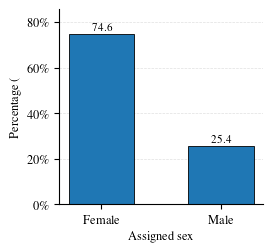

In [40]:
fig, ax = plt.subplots(figsize=(2.8, 2.6))

bars = ax.bar(
    dist_sexo["sexo_atribuido_en"].str.capitalize(),
    dist_sexo["percentual"],
    width=0.55,
    edgecolor="black",
    linewidth=0.6
)

ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Assigned sex")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

ax.set_ylim(0, dist_sexo["percentual"].max() * 1.15)

plt.tight_layout()
plt.savefig("figures/bar_plot_sex_distribution.pdf", bbox_inches="tight")
plt.savefig("figures/bar_plot_sex_distribution.png", bbox_inches="tight")
plt.show()

In [41]:
df_merged["cor_ou_raca"].value_counts()

# Rename to english: White, Black, Brown, Asian, Indigenous
df_merged["cor_ou_raca_en"] = df_merged["cor_ou_raca"].replace({
    "branca": "White",
    "preta": "Black",
    "parda": "Brown",
    "amarela": "Asian",
    "indígena": "Indigenous"
})

In [42]:
dist_cor = (
    df_merged["cor_ou_raca_en"]
    .value_counts()
    .rename_axis("cor_ou_raca_en")
    .reset_index(name="n")
)

dist_cor["percentual"] = 100 * dist_cor["n"] / len(df_merged)

display(dist_cor)

,cor_ou_raca_en,n,percentual
0,Brown,500,71.839080
1,White,195,28.017241
2,Black,1,0.143678


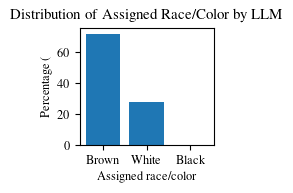

In [43]:
plt.figure(figsize=(2, 2))
plt.bar(dist_cor["cor_ou_raca_en"], dist_cor["percentual"])
plt.ylabel("Percentage (%)")
plt.xlabel("Assigned race/color")
plt.title("Distribution of Assigned Race/Color by LLM")
plt.tight_layout()
plt.show()

In [44]:
tab_sexo_cor = pd.crosstab(
    df_merged["sexo_atribuido_en"],
    df_merged["cor_ou_raca_en"],
)

display(tab_sexo_cor)

tab_sexo_cor_pct = pd.crosstab(
    df_merged["sexo_atribuido_en"],
    df_merged["cor_ou_raca_en"],
    normalize="index"
).mul(100).round(2)

display(tab_sexo_cor_pct)

tab_sexo_cor = pd.crosstab(
    df_merged["sexo_atribuido_en"],
    df_merged["cor_ou_raca_en"]
)

display(tab_sexo_cor)

# ordem_cor = ["Black", "White", "Brown", "Asian", "Indigenous"]
ordem_cor = ["Brown", "White", "Black"]

tab_sexo_cor = tab_sexo_cor.reindex(columns=ordem_cor, fill_value=0)

total_geral = tab_sexo_cor.to_numpy().sum()
tab_pct = 100 * tab_sexo_cor / total_geral

display(tab_pct.round(2))

cor_ou_raca_en,Black,Brown,White
sexo_atribuido_en,,,
Female,1,398,120
Male,0,102,75


cor_ou_raca_en,Black,Brown,White
sexo_atribuido_en,,,
Female,0.19,76.69,23.12
Male,0.00,57.63,42.37


cor_ou_raca_en,Black,Brown,White
sexo_atribuido_en,,,
Female,1,398,120
Male,0,102,75


cor_ou_raca_en,Brown,White,Black
sexo_atribuido_en,,,
Female,57.18,17.24,0.14
Male,14.66,10.78,0.00


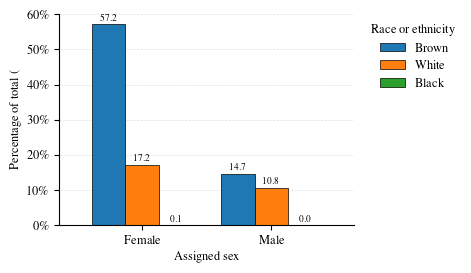

In [45]:
fig, ax = plt.subplots(figsize=(4.8, 2.8))

tab_pct.plot(
    kind="bar",
    ax=ax,
    width=0.78,
    edgecolor="black",
    linewidth=0.5
)

ax.set_xlabel("Assigned sex")
ax.set_ylabel("Percentage of total (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

ax.set_xticklabels(
    [str(label.get_text()).capitalize() for label in ax.get_xticklabels()],
    rotation=0
)

ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Race or ethnicity",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}" if bar.get_height() > 0 else "0.0"
        for bar in container
    ]
    ax.bar_label(container, labels=labels, fontsize=6.8, padding=1)

plt.tight_layout()
plt.savefig("figures/bar_plot_sex_distribution_by_race.pdf", bbox_inches="tight")
plt.savefig("figures/bar_plot_sex_distribution_by_race.png", bbox_inches="tight")
plt.show()

<>:40: SyntaxWarning: invalid escape sequence '\%'
<>:88: SyntaxWarning: invalid escape sequence '\%'
<>:40: SyntaxWarning: invalid escape sequence '\%'
<>:88: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_118858/618192938.py:40: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Percentage (\%)")
/tmp/ipykernel_118858/618192938.py:88: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Percentage (\%)")


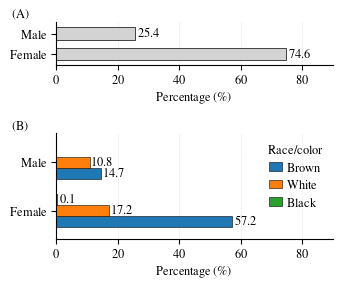

In [46]:
# -----------------------------
# Combined vertical figure
# One-column IEEE figure
# -----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.5, 3.0),
    gridspec_kw={"height_ratios": [0.55, 1.35]}
)

# -----------------------------
# Common x-axis limit for both panels
# -----------------------------
# xmax = max(
#     dist_sexo["percentual"].max(),
#     tab_pct.to_numpy().max()
# ) * 1.25

# =============================
# Panel A: assigned sex
# =============================
ax = axes[0]

# Manual y positions make bars closer together
spacing = 0.45
y_pos = np.arange(len(dist_sexo)) * spacing

bars = ax.barh(
    y_pos,
    dist_sexo["percentual"],
    height=0.28,
    edgecolor="black",
    linewidth=0.5,
    color="lightgray"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(dist_sexo["sexo_atribuido_en"].str.capitalize())

ax.set_xlabel("Percentage (\%)")
ax.set_ylabel("")
# ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}",
        ha="left",
        va="center",
        # fontsize=10
    )

ax.set_xlim(0, 90)

# Tighten vertical limits around bars
ax.set_ylim(y_pos[0] - 0.25, y_pos[-1] + 0.25)

ax.text(
    -0.16, 1.3, "(A)",
    transform=ax.transAxes,
    # fontsize=10,
    fontweight="bold",
    va="top"
)

# =============================
# Panel B: assigned sex × race/color
# =============================
ax = axes[1]

tab_pct.plot(
    kind="barh",
    ax=ax,
    width=0.7,
    edgecolor="black",
    linewidth=0.4,
    legend=False
)

ax.set_xlabel("Percentage (\%)")
ax.set_ylabel("")
# ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for container in ax.containers:
    labels = [
        f"{bar.get_width():.1f}" if bar.get_width() > 0 else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        # fontsize=10,
        padding=2
    )

ax.set_xlim(0, 90)

ax.text(
    -0.16, 1.12, "(B)",
    transform=ax.transAxes,
    # fontsize=10,
    fontweight="bold",
    va="top"
)

# Legend above Panel B
ax.legend(
    title="Race/color",
    frameon=False,          # Mantém sem borda para um visual mais limpo
    loc="upper right",      # Coloca no canto inferior direito (mude para "upper right" se preferir)
    ncol=1,                 # Mudei para 1 coluna para não invadir as barras, mas pode voltar para 2 se couber
    handlelength=1.1,
    handletextpad=0.4
)

plt.tight_layout(h_pad=1.0)

plt.savefig(
    "figures/bar_plot_sex_and_sex_race_distribution.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "figures/bar_plot_sex_and_sex_race_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

##### Columns and Proportions to Help the Analysis

In [47]:
df_merged["llm_feminino"] = df_merged["sexo_atribuido"].map({
    "feminino": 1,
    "masculino": 0,
    "nao_informado": np.nan
})

df_merged["llm_masculino"] = df_merged["sexo_atribuido"].map({
    "feminino": 0,
    "masculino": 1,
    "nao_informado": np.nan
})

df_merged["llm_branca"] = (df_merged["cor_ou_raca"] == "branca").astype(int)
df_merged["llm_preta"] = (df_merged["cor_ou_raca"] == "preta").astype(int)
df_merged["llm_parda"] = (df_merged["cor_ou_raca"] == "parda").astype(int)
df_merged["llm_amarela"] = (df_merged["cor_ou_raca"] == "amarela").astype(int)
df_merged["llm_indigena"] = (df_merged["cor_ou_raca"] == "indigena").astype(int)

In [48]:
colunas_ibge = [
    "Pessoas_Total",
    "Pessoas_Branca",
    "Pessoas_Preta",
    "Pessoas_Amarela",
    "Pessoas_Parda",
    "Pessoas_Indígena",
    "Homens_Total",
    "Homens_Branca",
    "Homens_Preta",
    "Homens_Amarela",
    "Homens_Parda",
    "Homens_Indígena",
    "Mulheres_Total",
    "Mulheres_Branca",
    "Mulheres_Preta",
    "Mulheres_Amarela",
    "Mulheres_Parda",
    "Mulheres_Indígena",
]

for col in colunas_ibge:
    df_merged[col] = (
        df_merged[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

df_merged["prop_mulheres_ibge"] = df_merged["Mulheres_Total"] / df_merged["Pessoas_Total"]
df_merged["prop_homens_ibge"] = df_merged["Homens_Total"] / df_merged["Pessoas_Total"]
df_merged["prop_branca_ibge"] = df_merged["Pessoas_Branca"] / df_merged["Pessoas_Total"]
df_merged["prop_preta_ibge"] = df_merged["Pessoas_Preta"] / df_merged["Pessoas_Total"]
df_merged["prop_parda_ibge"] = df_merged["Pessoas_Parda"] / df_merged["Pessoas_Total"]
df_merged["prop_amarela_ibge"] = df_merged["Pessoas_Amarela"] / df_merged["Pessoas_Total"]
df_merged["prop_indigena_ibge"] = df_merged["Pessoas_Indígena"] / df_merged["Pessoas_Total"]

##### Scatter Plot: IBGE Proportion vs. LLMs Proportion

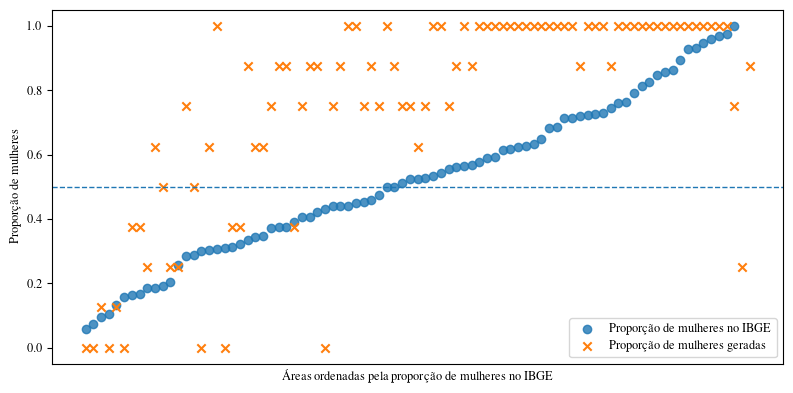

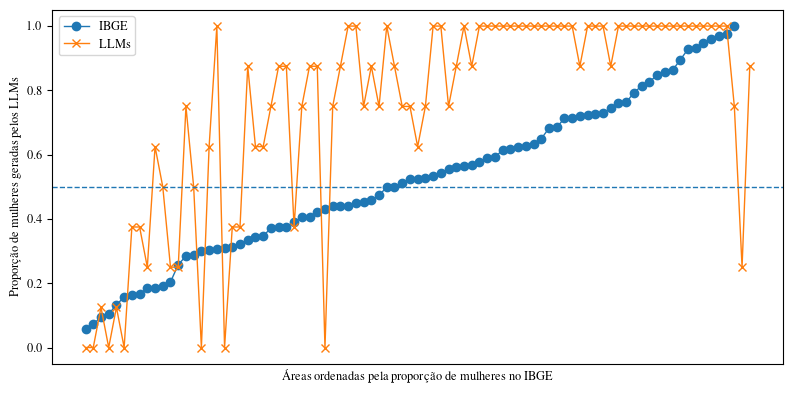

In [49]:
# Agregar por graduação
plot_df = (
    df_merged.groupby(["graduacao_codigo", "graduacao_descricao"], as_index=False)
    .agg(
        prop_mulheres_ibge=("prop_mulheres_ibge", "mean"),
        prop_mulheres_llm=("llm_feminino", "mean"),
        n_respostas=("llm_feminino", "count")
    )
)

# Ordenar da graduação mais masculina para a mais feminina segundo o IBGE
plot_df = plot_df.sort_values("prop_mulheres_ibge").reset_index(drop=True)
plot_df["idx"] = np.arange(len(plot_df))

plt.figure(figsize=(8, 4))

plt.scatter(
    plot_df["idx"],
    plot_df["prop_mulheres_ibge"],
    label="Proporção de mulheres no IBGE",
    alpha=0.8
)

plt.scatter(
    plot_df["idx"],
    plot_df["prop_mulheres_llm"],
    marker="x",
    label="Proporção de mulheres geradas"
)

plt.axhline(0.5, linestyle="--", linewidth=1)

plt.xticks([])  # remove nomes dos cursos do eixo x

plt.ylabel("Proporção de mulheres")
plt.xlabel("Áreas ordenadas pela proporção de mulheres no IBGE")
# plt.title("Mulheres geradas pelo LLM vs proporção real de mulheres por graduação")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))

plt.plot(
    plot_df["idx"],
    plot_df["prop_mulheres_ibge"],
    marker="o",
    linewidth=1,
    label="IBGE"
)

plt.plot(
    plot_df["idx"],
    plot_df["prop_mulheres_llm"],
    marker="x",
    linewidth=1,
    label="LLMs"
)

plt.axhline(0.5, linestyle="--", linewidth=1)

plt.xticks([])

plt.ylabel("Proporção de mulheres geradas pelos LLMs")
plt.xlabel("Áreas ordenadas pela proporção de mulheres no IBGE")
# plt.title("Proporção de mulheres: LLM vs IBGE por graduação")
plt.legend()
plt.tight_layout()
plt.savefig("figures/scatter_plot_women_ibge_vs_llm.pdf", bbox_inches="tight")
plt.savefig("figures/scatter_plot_women_ibge_vs_llm.png", bbox_inches="tight")
plt.show()

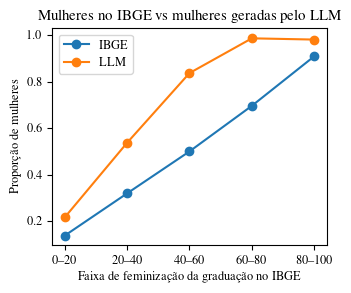

In [50]:
df_merged["faixa_feminizacao"] = pd.cut(
    df_merged["prop_mulheres_ibge"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[
        "0–20%",
        "20–40%",
        "40–60%",
        "60–80%",
        "80–100%"
    ],
    include_lowest=True
)

fig_df = (
    df_merged.groupby("faixa_feminizacao", observed=False)
    .agg(
        n=("graduacao_codigo", "count"),
        prop_mulheres_ibge=("prop_mulheres_ibge", "mean"),
        prop_mulheres_llm=("llm_feminino", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(3.5, 3))

plt.plot(
    fig_df["faixa_feminizacao"].astype(str),
    fig_df["prop_mulheres_ibge"],
    marker="o",
    label="IBGE"
)

plt.plot(
    fig_df["faixa_feminizacao"].astype(str),
    fig_df["prop_mulheres_llm"],
    marker="o",
    label="LLM"
)

plt.ylabel("Proporção de mulheres")
plt.xlabel("Faixa de feminização da graduação no IBGE")
plt.title("Mulheres no IBGE vs mulheres geradas pelo LLM")
plt.legend()
plt.tight_layout()
plt.show()

##### Percentage of Women of each Model vs. IBGE Proportion

In [51]:
ibge_grad = df_merged.drop_duplicates("graduacao_codigo").copy()

prop_mulheres_ibge_ref = (
    ibge_grad["Mulheres_Total"].sum() / ibge_grad["Pessoas_Total"].sum()
)

prop_mulheres_ibge_ref

prop_por_modelo = (
    df_merged
    .groupby("modelo")
    .agg(
        prop_mulheres_llm=("llm_feminino", "mean"),
        n_graduacoes=("graduacao_codigo", "nunique")
    )
    .reset_index()
)

prop_por_modelo["prop_mulheres_ibge_ref"] = prop_mulheres_ibge_ref

prop_por_modelo = prop_por_modelo.sort_values("prop_mulheres_llm")

display(prop_por_modelo)

,modelo,prop_mulheres_llm,n_graduacoes,prop_mulheres_ibge_ref
3,google/gemma-4-31B-it,0.459770,87,0.595245
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,0.666667,87,0.595245
5,mistralai/Mistral-Small-3.2-24B-Instruct-2506,0.666667,87,0.595245
7,sabia-4,0.781609,87,0.595245
0,Qwen/Qwen3-235B-A22B-Instruct-2507,0.839080,87,0.595245
6,openai/gpt-oss-120b,0.839080,87,0.595245
2,google/gemini-2.5-flash,0.850575,87,0.595245
1,deepseek-ai/DeepSeek-V4-Pro,0.862069,87,0.595245


In [52]:
model_name_map = {
    "openai/gpt-oss-120b": "GPT-OSS-120B",
    "google/gemini-2.5-flash": "Gemini-2.5-Flash",
    "google/gemma-4-31B-it": "Gemma-4-31B",
    "sabia-4": "Sabiá-4",
    "meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8": "Llama-4-Maverick",
    "deepseek-ai/DeepSeek-V4-Pro": "DeepSeek-V4-Pro",
    "mistralai/Mistral-Small-3.2-24B-Instruct-2506": "Mistral-Small-24B",
    "Qwen/Qwen3-235B-A22B-Instruct-2507": "Qwen3-235B-A22B",
    "nvidia/NVIDIA-Nemotron-3-Super-120B-A12B": "Nemotron-3-Super",
}

<>:31: SyntaxWarning: invalid escape sequence '\%'
<>:31: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_118858/1786245080.py:31: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Percentage (\%)")


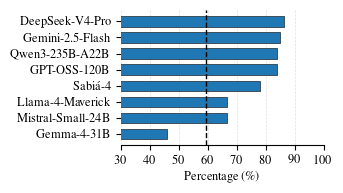

In [53]:
# Ordenar modelos alfabeticamente
# plot_df = prop_por_modelo.sort_values("modelo", ascending=True).copy()
plot_df = prop_por_modelo.sort_values(
    "prop_mulheres_llm",
    ascending=False
).copy()
plot_df["modelo_plot"] = plot_df["modelo"].replace(model_name_map)

# Percentage of women
plot_df["pct_mulheres_llm"] = plot_df["prop_mulheres_llm"] * 100

fig, ax = plt.subplots(figsize=(3.5, 2.0))

bars = ax.barh(
    plot_df["modelo_plot"],
    plot_df["pct_mulheres_llm"],
    height=0.65,
    edgecolor="black",
    linewidth=0.4,
    label="LLMs"
)

ax.axvline(
    100 * prop_mulheres_ibge_ref,
    linestyle="--",
    linewidth=1.0,
    color="black",
    label=f"IBGE ({100 * prop_mulheres_ibge_ref:.0f})"
)

ax.set_xlabel("Percentage (\%)")
ax.set_ylabel("")
ax.set_xlim(30, 100)
ax.set_xticks(np.arange(30, 101, 10))

ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Mantém ordem alfabética de cima para baixo
ax.invert_yaxis()

# Rótulos nas barras
# for bar in bars:
#     width = bar.get_width()
#     if bar.get_width() < 60 and bar.get_width() > 50:
#         ax.text(
#             width + 4.5,
#             bar.get_y() + bar.get_height() / 2,
#             f"{width:.1f}%",
#             va="center",
#             ha="right",
#             color="white",
#             # fontsize=10
#         )
#     else:
#       ax.text(
#           width + 2.5,
#           bar.get_y() + bar.get_height() / 2,
#           f"{width:.0f}",
#           va="center",
#           ha="left",
#           # fontsize=10
#       )

# ax.legend(
#     frameon=False,
#     loc="lower right"
# )

plt.tight_layout()
plt.savefig("figures/bar_plot_women_by_model_vs_ibge.pdf", bbox_inches="tight")
plt.savefig("figures/bar_plot_women_by_model_vs_ibge.png", bbox_inches="tight")
plt.show()

##### LLMs vs. IBGE per Detailed Field of Undergraduate Course (Biggest Differences)

In [54]:
por_graduacao = (
    df_merged.dropna(subset=["prop_mulheres_ibge"])
    .groupby(["graduacao_codigo", "graduacao_descricao"], as_index=False)
    .agg(
        prop_mulheres_ibge=("prop_mulheres_ibge", "mean"),
        prop_mulheres_llm=("llm_feminino", "mean"),
        n_modelos=("modelo", "nunique")
    )
)

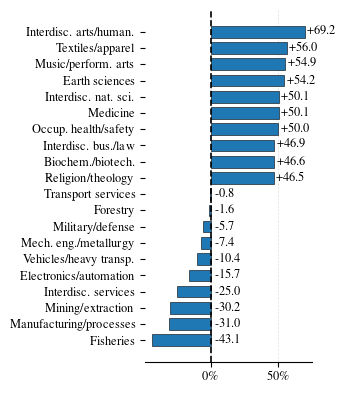

In [55]:
# Diferença entre LLM e IBGE
por_graduacao["erro_mulheres"] = (
    por_graduacao["prop_mulheres_llm"]
    - por_graduacao["prop_mulheres_ibge"]
)

# Top discrepâncias
top_erros = pd.concat([
    por_graduacao.nsmallest(10, "erro_mulheres"),
    por_graduacao.nlargest(10, "erro_mulheres")
]).sort_values("erro_mulheres").copy()

# Usar abreviação do curso
top_erros["graduacao_abrev"] = (
    top_erros["graduacao_descricao"]
    .map(abreviacoes_cursos_en)
    .fillna(top_erros["graduacao_descricao"])
)

fig, ax = plt.subplots(figsize=(3.5, 4.0))

bars = ax.barh(
    top_erros["graduacao_abrev"],
    top_erros["erro_mulheres"],
    edgecolor="black",
    linewidth=0.4,
    height=0.72
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="black"
)

# ax.set_xlabel("Diferença na proporção de mulheres (LLM − IBGE)")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1, decimals=0)
)

ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# for bar in bars:
#     width = bar.get_width()

#     ax.text(
#         width + (0.005 if width >= 0 else -0.005),
#         bar.get_y() + bar.get_height() / 2,
#         f"{width:+.1%}",
#         va="center",
#         ha="left" if width >= 0 else "right",
#         fontsize=7
#     )

for bar in bars:
    width = bar.get_width()
    
    # Se for positivo, coloca na ponta da barra (width + offset)
    if width >= 0:
        x_pos = width + 0.02
        align = "left"
    # Se for negativo, fixa encostado no eixo zero (-offset)
    else:
        x_pos = +0.03
        align = "left" # Mantém o texto "empurrado" para a esquerda do zero

    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f"{width:+.1%}",
        va="center",
        ha=align,
        # fontsize=7
    )

plt.tight_layout()

plt.savefig(
    "figures/bar_plot_gender_discrepancies_graduation_detailed_field.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "figures/bar_plot_gender_discrepancies_graduation_detailed_field.png",
    bbox_inches="tight"
)

plt.show()

##### LLMs MAE  on IBGE

In [56]:
por_modelo = (
    df_merged.dropna(subset=["prop_mulheres_ibge"])
    .groupby("modelo")
    .agg(
        n=("graduacao_codigo", "count"),
        prop_mulheres_llm=("llm_feminino", "mean"),
        prop_mulheres_ibge_media=("prop_mulheres_ibge", "mean"),
    )
    .reset_index()
)

por_modelo["erro_medio"] = (
    por_modelo["prop_mulheres_llm"] - por_modelo["prop_mulheres_ibge_media"]
)

# Erro absoluto por linha modelo-graduação
df_merged["erro_mulher_abs"] = (df_merged["llm_feminino"] - df_merged["prop_mulheres_ibge"]).abs()

mae_modelo = (
    df_merged.dropna(subset=["erro_mulher_abs"])
    .groupby("modelo")
    .agg(
        mae_genero=("erro_mulher_abs", "mean"),
        prop_feminino=("llm_feminino", "mean")
    )
    .reset_index()
)

por_modelo = por_modelo.merge(mae_modelo, on="modelo", how="left")

display(por_modelo.sort_values("mae_genero"))

,modelo,n,prop_mulheres_llm,prop_mulheres_ibge_media,erro_medio,mae_genero,prop_feminino
3,google/gemma-4-31B-it,85,0.470588,0.520593,-0.050005,0.333642,0.470588
5,mistralai/Mistral-Small-3.2-24B-Instruct-2506,85,0.670588,0.520593,0.149995,0.338353,0.670588
4,meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,85,0.670588,0.520593,0.149995,0.341154,0.670588
7,sabia-4,85,0.788235,0.520593,0.267642,0.360550,0.788235
6,openai/gpt-oss-120b,85,0.847059,0.520593,0.326466,0.384662,0.847059
0,Qwen/Qwen3-235B-A22B-Instruct-2507,85,0.847059,0.520593,0.326466,0.391233,0.847059
2,google/gemini-2.5-flash,85,0.847059,0.520593,0.326466,0.394321,0.847059
1,deepseek-ai/DeepSeek-V4-Pro,85,0.858824,0.520593,0.338231,0.414094,0.858824


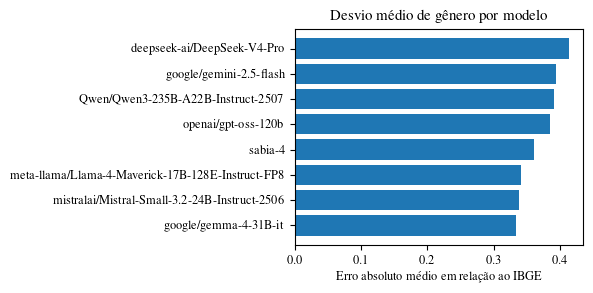

In [57]:
plot_modelo = por_modelo.sort_values("mae_genero")

plt.figure(figsize=(6, 3))

plt.barh(
    plot_modelo["modelo"],
    plot_modelo["mae_genero"]
)

plt.xlabel("Erro absoluto médio em relação ao IBGE")
plt.ylabel("")
plt.title("Desvio médio de gênero por modelo")
plt.tight_layout()
plt.show()

##### Percentage of Women: LLMs vs. IBGE on General Fields

In [58]:
# Get the names of the group
group_names = df_merged["grupo"].unique()
print(group_names)

<StringArray>
[                                                  'Educação',
                                        'Artes e humanidades',
                 'Ciências sociais, comunicação e informação',
                          'Negócios, administração e direito',
                'Ciências naturais, matemática e estatística',
 'Computação e Tecnologias da Informação e Comunicação (TIC)',
                          'Engenharia, produção e construção',
             'Agricultura, silvicultura, pesca e veterinária',
                                          'Saúde e bem-estar',
                                                   'Serviços']
Length: 10, dtype: str


In [59]:
grupo_map_en = {
    "Computação e Tecnologias da Informação e Comunicação (TIC)": "Computing and Information and Communication Technologies",
    "Engenharia, produção e construção": "Engineering, Manufacturing and Construction",
    "Agricultura, silvicultura, pesca e veterinária": "Agriculture, Forestry, Fisheries and Veterinary",
    "Ciências naturais, matemática e estatística": "Natural Sciences, Mathematics and Statistics",
    "Serviços": "Services",
    "Artes e humanidades": "Arts and Humanities",
    "Negócios, administração e direito": "Business, Administration and Law",
    "Ciências sociais, comunicação e informação": "Social Sciences, Journalism and Information",
    "Saúde e bem-estar": "Health and Welfare",
    "Educação": "Education",
}

grupo_map_en_abbrev = {
    "Computação e Tecnologias da Informação e Comunicação (TIC)": "ICT",
    "Engenharia, produção e construção": "Engineering",
    "Agricultura, silvicultura, pesca e veterinária": "Agriculture",
    "Ciências naturais, matemática e estatística": "Nat. Sci. & Math",
    "Serviços": "Services",
    "Artes e humanidades": "Arts & Hum.",
    "Negócios, administração e direito": "Business & Law",
    "Ciências sociais, comunicação e informação": "Soc. Sci. & Info.",
    "Saúde e bem-estar": "Health & Welfare",
    "Educação": "Education",
}

In [60]:
df_merged["grupo_en"] = df_merged["grupo"].map(grupo_map_en)

In [61]:
por_area = (
    df_merged.dropna(subset=["prop_mulheres_ibge"])
    .groupby("grupo_en")
    .agg(
        n_respostas=("modelo", "count"),
        n_graduacoes=("graduacao_codigo", "nunique"),
        prop_mulheres_ibge=("prop_mulheres_ibge", "mean"),
        prop_mulheres_llm=("llm_feminino", "mean")
    )
    .reset_index()
)

por_area["erro_mulheres"] = (
    por_area["prop_mulheres_llm"] - por_area["prop_mulheres_ibge"]
)

por_area = por_area.sort_values("prop_mulheres_ibge")

display(por_area)

,grupo_en,n_respostas,n_graduacoes,prop_mulheres_ibge,prop_mulheres_llm,erro_mulheres
3,Computing and Information and Communication Te...,48,6,0.229018,0.416667,0.187648
5,"Engineering, Manufacturing and Construction",112,14,0.324962,0.437500,0.112538
0,"Agriculture, Forestry, Fisheries and Veterinary",40,5,0.427132,0.500000,0.072868
7,"Natural Sciences, Mathematics and Statistics",72,9,0.485035,0.819444,0.334410
8,Services,80,10,0.527064,0.675000,0.147936
1,Arts and Humanities,80,10,0.544231,0.937500,0.393269
2,"Business, Administration and Law",64,8,0.556417,0.843750,0.287333
9,"Social Sciences, Journalism and Information",48,6,0.630571,0.958333,0.327762
6,Health and Welfare,88,11,0.725719,0.977273,0.251554
4,Education,48,6,0.815872,0.979167,0.163294


<>:40: SyntaxWarning: invalid escape sequence '\%'
<>:40: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_118858/3216459176.py:40: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Percentage of women (\%)", fontsize=8)


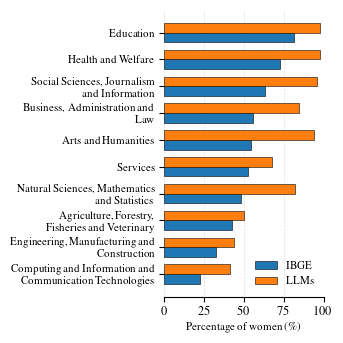

In [71]:
import textwrap  # <-- Biblioteca nativa do Python para quebrar strings longas
from matplotlib.ticker import FuncFormatter  # <-- Substitui o PercentFormatter

# Opcional: ordenar por proporção do IBGE
plot_area = por_area.sort_values("prop_mulheres_ibge", ascending=True).copy()

y = np.arange(len(plot_area))
largura = 0.36

# Talvez seja necessário aumentar um pouquinho a largura da figura (o primeiro valor do figsize) 
# caso os textos quebrados ainda fiquem apertados.
fig, ax = plt.subplots(figsize=(3.5, 3.5))

ax.barh(
    y - largura / 2,
    plot_area["prop_mulheres_ibge"],
    height=largura,
    label="IBGE",
    edgecolor="black",
    linewidth=0.4
)

ax.barh(
    y + largura / 2,
    plot_area["prop_mulheres_llm"],
    height=largura,
    label="LLMs",
    edgecolor="black",
    linewidth=0.4
)

ax.set_yticks(y)

# 1. QUEBRANDO O TEXTO LONGO DO EIXO Y
# O parâmetro 'width=15' define o número máximo de caracteres por linha antes de quebrar.
# Ajuste esse número para mais ou para menos conforme ficar melhor na sua figura!
labels_quebradas = [textwrap.fill(str(label), width=30) for label in plot_area["grupo_en"]]
ax.set_yticklabels(labels_quebradas, fontsize=8)

ax.set_xlabel("Percentage of women (\%)", fontsize=8)
ax.set_ylabel("", fontsize=8)
ax.set_xlim(0, 1)

# Set x label size
ax.xaxis.label.set_size(8)

# 2. REMOVENDO O SÍMBOLO DE % DO EIXO X
# Como seus dados vão de 0.2 a 1, multiplicamos por 100 no formatador para mostrar 20, 40, 60...
# sem adicionar o símbolo de "%" no final.
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x*100)}"))

ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(frameon=False, loc="lower right", fontsize=8)

plt.tight_layout()

plt.savefig("figures/bar_plot_women_distribution_by_general_field.pdf", bbox_inches="tight")
plt.savefig("figures/bar_plot_women_distribution_by_general_field.png", bbox_inches="tight")

plt.show()

##### Color: LLMs vs. IBGE

In [63]:
dist_cor_llm = pd.DataFrame({
    "cor_ou_raca": ["branca", "preta", "parda", "amarela", "indigena"],
    "prop_llm": [
        df_merged["llm_branca"].mean(),
        df_merged["llm_preta"].mean(),
        df_merged["llm_parda"].mean(),
        df_merged["llm_amarela"].mean(),
        df_merged["llm_indigena"].mean(),
    ]
})

In [64]:
total_pessoas = df_merged.drop_duplicates("graduacao_codigo")["Pessoas_Total"].sum()

ibge_por_grad = df_merged.drop_duplicates("graduacao_codigo")

dist_cor_ibge = pd.DataFrame({
    "cor_ou_raca": ["branca", "preta", "parda", "amarela", "indigena"],
    "prop_ibge": [
        ibge_por_grad["Pessoas_Branca"].sum() / ibge_por_grad["Pessoas_Total"].sum(),
        ibge_por_grad["Pessoas_Preta"].sum() / ibge_por_grad["Pessoas_Total"].sum(),
        ibge_por_grad["Pessoas_Parda"].sum() / ibge_por_grad["Pessoas_Total"].sum(),
        ibge_por_grad["Pessoas_Amarela"].sum() / ibge_por_grad["Pessoas_Total"].sum(),
        ibge_por_grad["Pessoas_Indígena"].sum() / ibge_por_grad["Pessoas_Total"].sum(),
    ]
})

comparacao_cor = dist_cor_ibge.merge(dist_cor_llm, on="cor_ou_raca")
comparacao_cor["diferenca"] = comparacao_cor["prop_llm"] - comparacao_cor["prop_ibge"]

display(comparacao_cor)

,cor_ou_raca,prop_ibge,prop_llm,diferenca
0,branca,0.625433,0.280172,-0.345260
1,preta,0.070284,0.001437,-0.068847
2,parda,0.290329,0.718391,0.428062
3,amarela,0.011733,0.000000,-0.011733
4,indigena,0.002007,0.000000,-0.002007


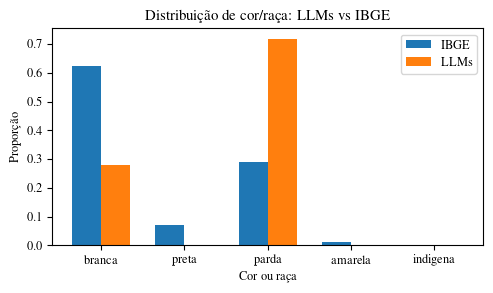

In [65]:
x = np.arange(len(comparacao_cor))
largura = 0.35

plt.figure(figsize=(5, 3))

plt.bar(
    x - largura/2,
    comparacao_cor["prop_ibge"],
    width=largura,
    label="IBGE"
)

plt.bar(
    x + largura/2,
    comparacao_cor["prop_llm"],
    width=largura,
    label="LLMs"
)

plt.xticks(x, comparacao_cor["cor_ou_raca"])
plt.ylabel("Proporção")
plt.xlabel("Cor ou raça")
plt.title("Distribuição de cor/raça: LLMs vs IBGE")
plt.legend()
plt.tight_layout()
plt.show()

##### Color Proportion of Each LLM

,branca,preta,parda,amarela,indigena
modelo,,,,,
Qwen/Qwen3-235B-A22B-Instruct-2507,0.609195,0.000000,0.390805,0.0,0.0
deepseek-ai/DeepSeek-V4-Pro,0.333333,0.000000,0.666667,0.0,0.0
google/gemini-2.5-flash,0.195402,0.011494,0.793103,0.0,0.0
google/gemma-4-31B-it,0.068966,0.000000,0.931034,0.0,0.0
meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8,0.505747,0.000000,0.494253,0.0,0.0
mistralai/Mistral-Small-3.2-24B-Instruct-2506,0.000000,0.000000,1.000000,0.0,0.0
openai/gpt-oss-120b,0.000000,0.000000,1.000000,0.0,0.0
sabia-4,0.528736,0.000000,0.471264,0.0,0.0


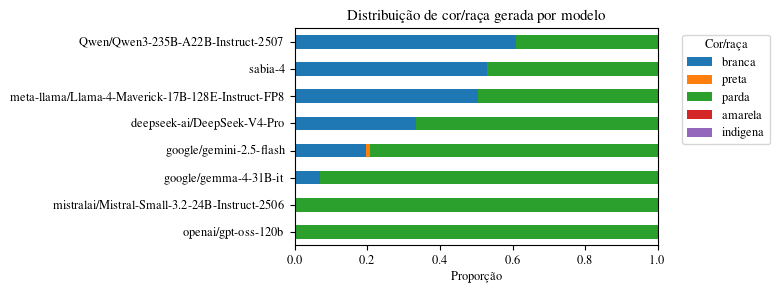

In [66]:
cor_por_modelo = (
    df_merged.groupby("modelo")
    .agg(
        branca=("llm_branca", "mean"),
        preta=("llm_preta", "mean"),
        parda=("llm_parda", "mean"),
        amarela=("llm_amarela", "mean"),
        indigena=("llm_indigena", "mean")
    )
)

display(cor_por_modelo)

cor_por_modelo_plot = cor_por_modelo.sort_values("branca")

ax = cor_por_modelo_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 3)
)

ax.set_xlabel("Proporção")
ax.set_ylabel("")
ax.set_title("Distribuição de cor/raça gerada por modelo")
plt.legend(title="Cor/raça", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

##### Color and Sex: LLMs vs. IBGE

In [67]:
dist_llm_intersec = (
    df_merged.groupby(["sexo_atribuido", "cor_ou_raca"])
    .size()
    .reset_index(name="n_llm")
)

dist_llm_intersec["prop_llm"] = dist_llm_intersec["n_llm"] / dist_llm_intersec["n_llm"].sum()

display(dist_llm_intersec)

,sexo_atribuido,cor_ou_raca,n_llm,prop_llm
0,feminino,branca,120,0.172414
1,feminino,parda,398,0.571839
2,feminino,preta,1,0.001437
3,masculino,branca,75,0.107759
4,masculino,parda,102,0.146552


In [68]:
dados_ibge_intersec = [
    {
        "sexo": "masculino",
        "cor_ou_raca": "branca",
        "n_ibge": ibge_grad["Homens_Branca"].sum()
    },
    {
        "sexo": "masculino",
        "cor_ou_raca": "preta",
        "n_ibge": ibge_grad["Homens_Preta"].sum()
    },
    {
        "sexo": "masculino",
        "cor_ou_raca": "parda",
        "n_ibge": ibge_grad["Homens_Parda"].sum()
    },
    {
        "sexo": "masculino",
        "cor_ou_raca": "amarela",
        "n_ibge": ibge_grad["Homens_Amarela"].sum()
    },
    {
        "sexo": "masculino",
        "cor_ou_raca": "indigena",
        "n_ibge": ibge_grad["Homens_Indígena"].sum()
    },
    {
        "sexo": "feminino",
        "cor_ou_raca": "branca",
        "n_ibge": ibge_grad["Mulheres_Branca"].sum()
    },
    {
        "sexo": "feminino",
        "cor_ou_raca": "preta",
        "n_ibge": ibge_grad["Mulheres_Preta"].sum()
    },
    {
        "sexo": "feminino",
        "cor_ou_raca": "parda",
        "n_ibge": ibge_grad["Mulheres_Parda"].sum()
    },
    {
        "sexo": "feminino",
        "cor_ou_raca": "amarela",
        "n_ibge": ibge_grad["Mulheres_Amarela"].sum()
    },
    {
        "sexo": "feminino",
        "cor_ou_raca": "indigena",
        "n_ibge": ibge_grad["Mulheres_Indígena"].sum()
    },
]

dist_ibge_intersec = pd.DataFrame(dados_ibge_intersec)

dist_ibge_intersec["prop_ibge"] = (
    dist_ibge_intersec["n_ibge"] / dist_ibge_intersec["n_ibge"].sum()
)

display(dist_ibge_intersec)

,sexo,cor_ou_raca,n_ibge,prop_ibge
0,masculino,branca,6434232.0,0.257241
1,masculino,preta,711608.0,0.028450
2,masculino,parda,2819158.0,0.112710
3,masculino,amarela,138277.0,0.005528
4,masculino,indigena,20388.0,0.000815
5,feminino,branca,9212725.0,0.368326
6,feminino,preta,1046730.0,0.041848
7,feminino,parda,4444243.0,0.177681
8,feminino,amarela,155264.0,0.006207
9,feminino,indigena,29818.0,0.001192


In [69]:
dist_llm_intersec = dist_llm_intersec.rename(columns={
    "sexo_atribuido": "sexo",
    "cor_ou_raca": "cor_ou_raca"
})

comparacao_intersec = dist_ibge_intersec.merge(
    dist_llm_intersec,
    on=["sexo", "cor_ou_raca"],
    how="left"
)

comparacao_intersec["n_llm"] = comparacao_intersec["n_llm"].fillna(0)
comparacao_intersec["prop_llm"] = comparacao_intersec["prop_llm"].fillna(0)

comparacao_intersec["diferenca_llm_ibge"] = (
    comparacao_intersec["prop_llm"] - comparacao_intersec["prop_ibge"]
)

# comparacao_intersec["razao_llm_ibge"] = (
#     comparacao_intersec["prop_llm"] / comparacao_intersec["prop_ibge"]
# )

display(
    comparacao_intersec.sort_values("diferenca_llm_ibge", ascending=False)
)

,sexo,cor_ou_raca,n_ibge,prop_ibge,n_llm,prop_llm,diferenca_llm_ibge
7,feminino,parda,4444243.0,0.177681,398.0,0.571839,0.394158
2,masculino,parda,2819158.0,0.112710,102.0,0.146552,0.033842
4,masculino,indigena,20388.0,0.000815,0.0,0.000000,-0.000815
9,feminino,indigena,29818.0,0.001192,0.0,0.000000,-0.001192
3,masculino,amarela,138277.0,0.005528,0.0,0.000000,-0.005528
8,feminino,amarela,155264.0,0.006207,0.0,0.000000,-0.006207
1,masculino,preta,711608.0,0.028450,0.0,0.000000,-0.028450
6,feminino,preta,1046730.0,0.041848,1.0,0.001437,-0.040412
0,masculino,branca,6434232.0,0.257241,75.0,0.107759,-0.149483
5,feminino,branca,9212725.0,0.368326,120.0,0.172414,-0.195912


In [70]:
english_labels = {
    "Masculino / Branca": "Male and white",
    "Masculino / Preta": "Male and black",
    "Masculino / Parda": "Male and brown",
    "Masculino / Amarela": "Male and asian",
    "Masculino / Indigena": "Male and indigenous",
    "Feminino / Branca": "Female and white",
    "Feminino / Preta": "Female and black",
    "Feminino / Parda": "Female and brown",
    "Feminino / Amarela": "Female and asian",
    "Feminino / Indigena": "Female and indigenous"
}

<>:37: SyntaxWarning: invalid escape sequence '\%'
<>:37: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_73157/1238375914.py:37: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Percentage (\%)")


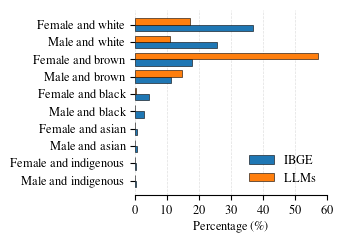

In [71]:
plot_df = comparacao_intersec.copy()

plot_df["grupo_intersec"] = (
    plot_df["sexo"].astype(str).str.capitalize()
    + " / "
    + plot_df["cor_ou_raca"].astype(str).str.capitalize()
).map(english_labels).fillna(plot_df["sexo"].astype(str).str.capitalize() + " / " + plot_df["cor_ou_raca"].astype(str).str.capitalize())

plot_df = plot_df.sort_values("prop_ibge", ascending=True).copy()

y = np.arange(len(plot_df))
largura = 0.36

fig, ax = plt.subplots(figsize=(3.5, 2.5))

ax.barh(
    y - largura / 2,
    plot_df["prop_ibge"] * 100,
    height=largura,
    label="IBGE",
    edgecolor="black",
    linewidth=0.4
)

ax.barh(
    y + largura / 2,
    plot_df["prop_llm"] * 100,
    height=largura,
    label="LLMs",
    edgecolor="black",
    linewidth=0.4
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["grupo_intersec"])

ax.set_xlabel("Percentage (\%)")
ax.set_ylabel("")
ax.set_xlim(0, max(plot_df["prop_ibge"].max(), plot_df["prop_llm"].max()) * 1.12)

# Put grid each 10 percentage points
ax.set_xticks(np.arange(0, 70, 10))
# ax.set_xlim(0, 70)

# ax.xaxis.set_major_formatter(
#     mtick.PercentFormatter(xmax=1, decimals=0)
# )

ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    "figures/bar_plot_intersectional_sex_race_distribution_vs_ibge.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "figures/bar_plot_intersectional_sex_race_distribution_vs_ibge.png",
    bbox_inches="tight"
)

plt.show()

##### Income (First Analysis)

<Figure size 300x300 with 0 Axes>

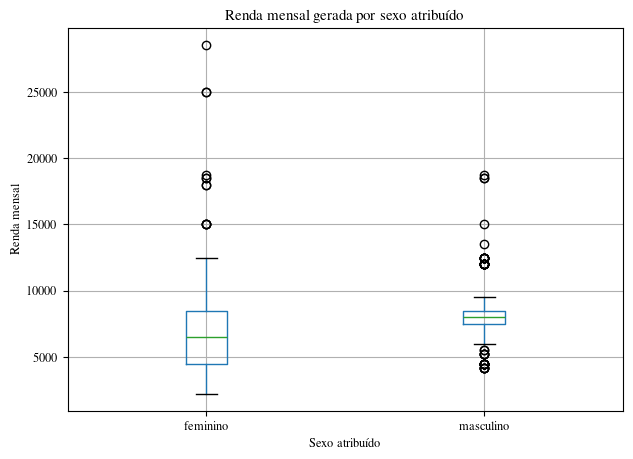

<Figure size 300x300 with 0 Axes>

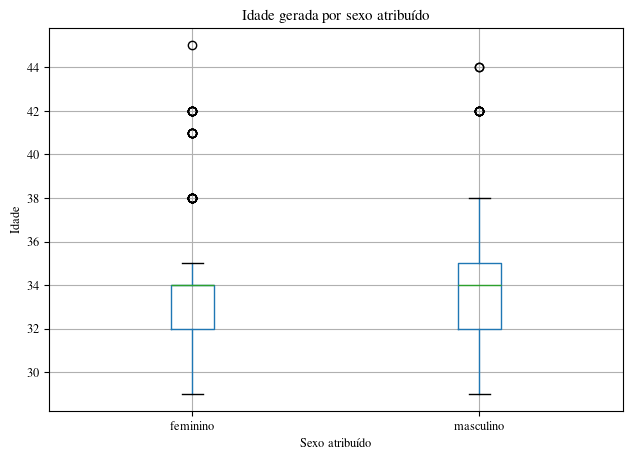

In [72]:
df_merged.groupby("sexo_atribuido").agg(
    idade_media=("idade", "mean"),
    idade_mediana=("idade", "median"),
    renda_media=("renda_mensal", "mean"),
    renda_mediana=("renda_mensal", "median"),
    n=("modelo", "count")
)

plt.figure(figsize=(3, 3))

df_merged.boxplot(
    column="renda_mensal",
    by="sexo_atribuido"
)

plt.suptitle("")
plt.title("Renda mensal gerada por sexo atribuído")
plt.xlabel("Sexo atribuído")
plt.ylabel("Renda mensal")
plt.tight_layout()
plt.show()

plt.figure(figsize=(3, 3))

df_merged.boxplot(
    column="idade",
    by="sexo_atribuido"
)

plt.suptitle("")
plt.title("Idade gerada por sexo atribuído")
plt.xlabel("Sexo atribuído")
plt.ylabel("Idade")
plt.tight_layout()
plt.show()

In [73]:
df_merged.groupby("cor_ou_raca").agg(
    idade_media=("idade", "mean"),
    idade_mediana=("idade", "median"),
    renda_media=("renda_mensal", "mean"),
    renda_mediana=("renda_mensal", "median"),
    n=("modelo", "count")
)

,idade_media,idade_mediana,renda_media,renda_mediana,n
cor_ou_raca,,,,,
branca,34.302564,34.0,8305.641026,8000.0,195
parda,33.646000,34.0,6722.800000,6500.0,500
preta,38.000000,38.0,4200.000000,4200.0,1


,sexo_atribuido,cor_ou_raca,renda_media,renda_mediana,n
0,feminino,branca,8020.000000,7500.0,120
1,feminino,parda,6421.105528,5650.0,398
2,feminino,preta,4200.000000,4200.0,1
3,masculino,branca,8762.666667,8000.0,75
4,masculino,parda,7900.000000,7500.0,102


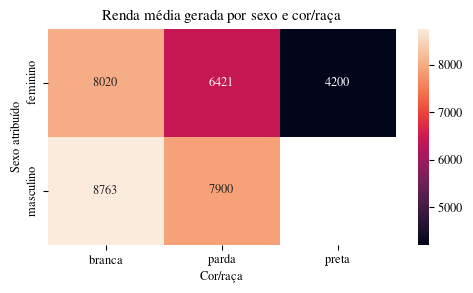

In [74]:
renda_sexo_cor = (
    df_merged.groupby(["sexo_atribuido", "cor_ou_raca"])
    .agg(
        renda_media=("renda_mensal", "mean"),
        renda_mediana=("renda_mensal", "median"),
        n=("modelo", "count")
    )
    .reset_index()
)

display(renda_sexo_cor)

pivot_renda = renda_sexo_cor.pivot(
    index="sexo_atribuido",
    columns="cor_ou_raca",
    values="renda_media"
)

plt.figure(figsize=(5, 3))
sns.heatmap(pivot_renda, annot=True, fmt=".0f")
plt.title("Renda média gerada por sexo e cor/raça")
plt.xlabel("Cor/raça")
plt.ylabel("Sexo atribuído")
plt.tight_layout()
plt.show()

In [75]:
estado_dist = (
    df_merged["estado"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

estado_dist.columns = ["estado", "percentual"]

display(estado_dist)

,estado,percentual
0,SP,81.178161
1,MG,11.781609
2,RJ,1.580460
3,PR,1.436782
4,SC,1.293103
5,DF,1.149425
6,MT,0.574713
7,PE,0.287356
8,BA,0.287356
9,GO,0.143678
